# ECC Benchmarking Suite
### KeyGeneration · Encrypt · Decrypt

**Setup requirements:**  
- SageMath installed and `sage` available on `PATH`  
- `KeyGeneration.py`, `Encrypt.py`, `Decrypt.py` in the **same directory** as this notebook  
- `pip install matplotlib numpy`

Each benchmark calls the sage scripts via `subprocess`, parses the printed `Time Taken` value, and plots the results.

In [1]:
import subprocess
import re
import os
import json
import time
import tempfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Configuration ──────────────────────────────────────────────────────────────
SAGE        = "python"          # change to full path if sage is not on PATH
SCRIPT_DIR  = Path(".")       # directory containing the .py scripts
RUNS        = 3               # repetitions per data-point (median is used)
TIMEOUT     = 600             # seconds before a single run is aborted

plt.rcParams.update({
    "figure.dpi":     130,
    "font.family":    "sans-serif",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.35,
})

COLOURS = ["#3B82F6", "#EF4444", "#10B981", "#F59E0B", "#8B5CF6"]

print("✓ Imports OK")

✓ Imports OK


In [2]:
# ── Helper utilities ───────────────────────────────────────────────────────────

def run_sage(args: list[str], cwd=None, timeout=TIMEOUT) -> tuple[str, float | None]:
    """Run `sage <args>` and return (stdout, parsed_time_seconds | None)."""
    cmd = [SAGE] + args
    try:
        result = subprocess.run(
            cmd, capture_output=True, text=True,
            cwd=str(cwd or SCRIPT_DIR), timeout=timeout
        )
        stdout = result.stdout + result.stderr
        m = re.search(r"Time Taken[:\s]+([\d.]+)s", stdout)
        elapsed = float(m.group(1)) if m else None
        if result.returncode != 0 and elapsed is None:
            print(f"  [WARN] non-zero exit ({result.returncode}): {stdout[:200]}")
        return stdout, elapsed
    except subprocess.TimeoutExpired:
        print(f"  [TIMEOUT] {' '.join(cmd)}")
        return "", None


def median_time(args: list[str], runs=RUNS, cwd=None) -> float | None:
    """Run RUNS times and return the median time (ignoring failed runs)."""
    times = []
    for _ in range(runs):
        _, t = run_sage(args, cwd=cwd)
        if t is not None:
            times.append(t)
    return float(np.median(times)) if times else None


def make_tmpdir() -> Path:
    """Create a temp directory pre-populated with the sage scripts."""
    tmpdir = Path(tempfile.mkdtemp())
    for script in ["KeyGeneration.py", "Encrypt.py", "Decrypt.py"]:
        src = SCRIPT_DIR / script
        if src.exists():
            shutil.copy(src, tmpdir / script)
    return tmpdir


def cleanup(tmpdir: Path):
    shutil.rmtree(str(tmpdir), ignore_errors=True)


print("✓ Helpers OK")

✓ Helpers OK


In [3]:
run_sage(["KeyGeneration.py", "3", "32", "1"])

('Time Taken: 0.015s\n', 0.015)

---
## 1  KeyGeneration — Key Size vs Time

Uses **Mode 3** (`bits`, `degree=1`) to sweep over a range of prime-field bit sizes.  
Predefined curves (Mode 2) are also included as reference points.

> ⚠️ Larger bit sizes (256 +) can take minutes. Adjust `BIT_SIZES` to taste.

In [13]:
# ── Bit sizes to sweep ─────────────────────────────────────────────────────────
BIT_SIZES = [32, 48, 64, 80, 96, 112, 128, 160, 192, 224, 256]
# Remove large sizes if you want faster runs:
# BIT_SIZES = [32, 48, 64, 80, 96, 128]

PREDEFINED = [
    ("secp256k1", 256),
    ("P-256",     256),
    ("curve25519",255),
]

keygen_times   = []   # (bits, time)
predefined_pts = []   # (bits, time, name)

print("Benchmarking KeyGeneration (Mode 3) …")
for bits in BIT_SIZES:
    t = median_time(["KeyGeneration.py", "3", str(bits), "1"])
    keygen_times.append((bits, t))
    status = f"{t:.3f}s" if t is not None else "FAILED"
    print(f"  bits={bits:>3}  →  {status}")

print("\nBenchmarking predefined curves (Mode 2) …")
for name, bits in PREDEFINED:
    t = median_time(["KeyGeneration.py", "2", name])
    predefined_pts.append((bits, t, name))
    status = f"{t:.3f}s" if t is not None else "FAILED"
    print(f"  {name:<12}  →  {status}")

print("\n✓ KeyGeneration benchmark done")

Benchmarking KeyGeneration (Mode 3) …
  bits= 32  →  0.012s
  bits= 48  →  0.014s
  bits= 64  →  0.036s
  bits= 80  →  0.056s
  bits= 96  →  0.065s
  bits=112  →  0.096s
  bits=128  →  0.126s
  bits=160  →  0.251s
  bits=192  →  0.582s
  bits=224  →  1.138s
  bits=256  →  1.427s

Benchmarking predefined curves (Mode 2) …
  secp256k1     →  0.146s
  P-256         →  0.052s
  curve25519    →  0.111s

✓ KeyGeneration benchmark done


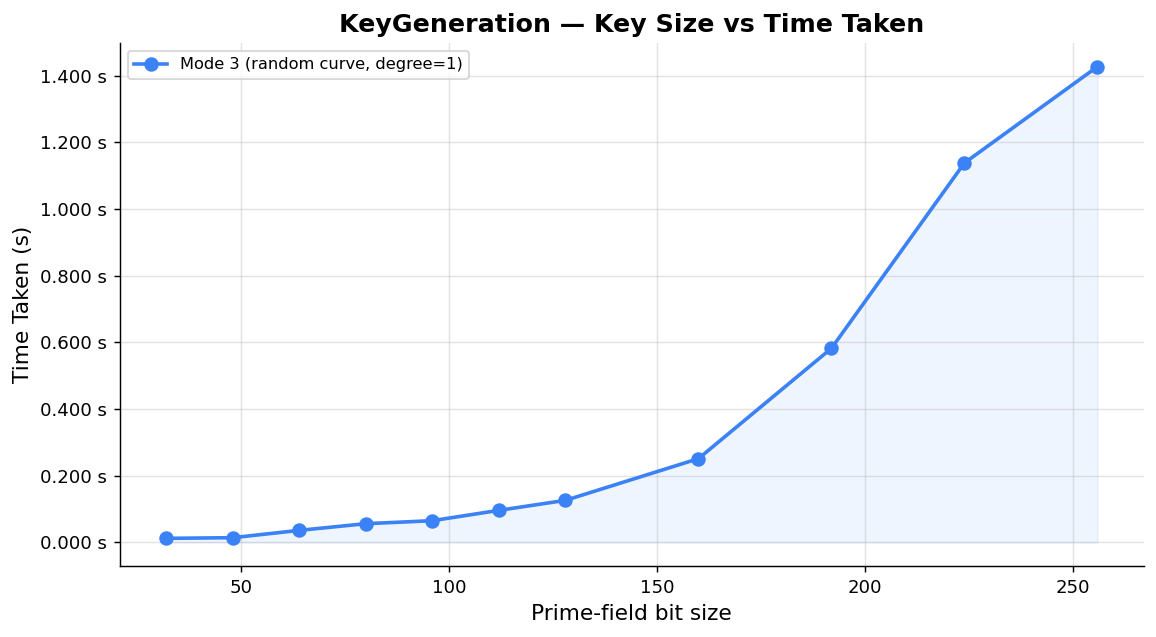

Saved → bench_keygen.png


In [14]:
# ── Plot ────────────────────────────────────────────────────────────────────────
valid = [(b, t) for b, t in keygen_times if t is not None]
xs, ys = zip(*valid) if valid else ([], [])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(xs, ys, "o-", color=COLOURS[0], linewidth=2,
        markersize=7, label="Mode 3 (random curve, degree=1)")

# Shade area under curve
ax.fill_between(xs, ys, alpha=0.08, color=COLOURS[0])

# Predefined curve markers
"""for bits, t, name in predefined_pts:
    if t is not None:
        ax.scatter([bits], [t], zorder=5, s=90, marker="D",
                   color=COLOURS[1], label=f"{name} (Mode 2)")
        ax.annotate(name, (bits, t), textcoords="offset points",
                    xytext=(8, 4), fontsize=8, color=COLOURS[1])
"""

ax.set_xlabel("Prime-field bit size", fontsize=12)
ax.set_ylabel("Time Taken (s)", fontsize=12)
ax.set_title("KeyGeneration — Key Size vs Time Taken", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f s"))
plt.tight_layout()
plt.savefig("bench_keygen.png", dpi=150)
plt.show()
print("Saved → bench_keygen.png")

---
## 2  Encrypt — Message Size vs Time (multiple key sizes)

For each key size a fresh key-pair is generated, then messages of increasing length are encrypted.

In [6]:
from pathlib import Path
import numpy as np

# ── Parameters ─────────────────────────────────────────────────────────────────
KEY_BITS_TO_TEST = [64, 96, 128, 192, 256]
MSG_SIZES_BYTES  = [10, 100, 1000, 5000, 10000, 20000, 30000, 50000, 75000, 100000] 
RUNS = 3 # Ensure RUNS is defined

# Load the sample text from big.txt as raw bytes
BIG_FILE_PATH = Path("big.txt")
if BIG_FILE_PATH.exists():
    # Reading as bytes automatically handles UTF-8 byte counts correctly
    SAMPLE_DATA = BIG_FILE_PATH.read_bytes()
else:
    print("Error: big.txt not found.")
    exit()

def make_message_file(path: Path, n_bytes: int) -> int:
    """Writes n_bytes to a file and returns the actual number of bytes written."""
    # Slice the data. This handles cases where n_bytes > file size.
    chunk = SAMPLE_DATA[:n_bytes]
    path.write_bytes(chunk)
    return len(chunk)

# Results: {bits: [(msg_bytes, time), ...]}
encrypt_results = {}

for bits in KEY_BITS_TO_TEST:
    print(f"\n── Key size: {bits} bits ──")
    tmpdir = make_tmpdir() # Assumes this helper exists in your script

    # 1. Generate keys for this bit size
    _, kt = run_sage(["KeyGeneration.py", "3", str(bits), "1"], cwd=tmpdir)
    if kt is None:
        print(f"  Key generation FAILED for {bits} bits — skipping.")
        cleanup(tmpdir)
        continue
    print(f"  KeyGen: {kt:.3f}s")

    times = []
    for n in MSG_SIZES_BYTES:
        msg_file = tmpdir / "message.txt"
        
        # Write file and get the exact byte count
        actual_byte_count = make_message_file(msg_file, n)

        run_times = []
        for _ in range(RUNS):
            _, t = run_sage(
                ["Encrypt.py", "1", "ecc_public_key.txt", "message.txt"],
                cwd=tmpdir
            )
            if t is not None:
                run_times.append(t)

        med = float(np.median(run_times)) if run_times else None
        
        # Store result using the actual byte count
        times.append((actual_byte_count, med))
        
        status = f"{med:.3f}s" if med is not None else "FAILED"
        print(f"  size={actual_byte_count:>5} bytes  →  {status}")

    encrypt_results[bits] = times
    cleanup(tmpdir)

print("\n✓ Encrypt benchmark done")


── Key size: 64 bits ──
  KeyGen: 0.036s
  size=   10 bytes  →  0.036s
  size=  100 bytes  →  0.037s
  size= 1000 bytes  →  0.053s
  size= 5000 bytes  →  0.122s
  size=10000 bytes  →  0.219s
  size=20000 bytes  →  0.414s
  size=30000 bytes  →  0.568s
  size=50000 bytes  →  0.978s
  size=75000 bytes  →  1.401s
  size=100000 bytes  →  1.864s

── Key size: 96 bits ──
  KeyGen: 0.083s
  size=   10 bytes  →  0.072s
  size=  100 bytes  →  0.073s
  size= 1000 bytes  →  0.080s
  size= 5000 bytes  →  0.131s
  size=10000 bytes  →  0.193s
  size=20000 bytes  →  0.307s
  size=30000 bytes  →  0.443s
  size=50000 bytes  →  0.635s
  size=75000 bytes  →  1.000s
  size=100000 bytes  →  1.272s

── Key size: 128 bits ──
  KeyGen: 0.136s
  size=   10 bytes  →  0.124s
  size=  100 bytes  →  0.128s
  size= 1000 bytes  →  0.132s
  size= 5000 bytes  →  0.179s
  size=10000 bytes  →  0.237s
  size=20000 bytes  →  0.340s
  size=30000 bytes  →  0.458s
  size=50000 bytes  →  0.666s
  size=75000 bytes  →  0.958s
 

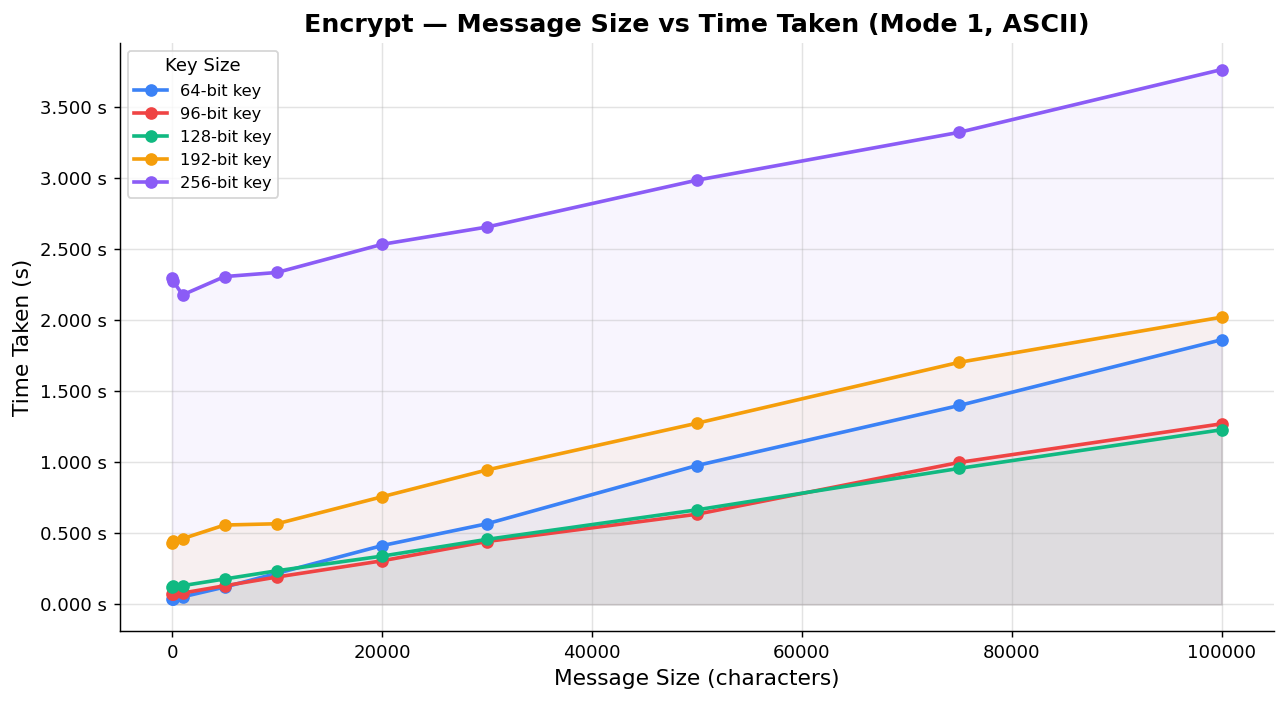

Saved → bench_encrypt.png


In [7]:
# ── Plot ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))

for idx, (bits, data) in enumerate(sorted(encrypt_results.items())):
    valid = [(x, y) for x, y in data if y is not None]
    if not valid:
        continue
    xs, ys = zip(*valid)
    color = COLOURS[idx % len(COLOURS)]
    ax.plot(xs, ys, "o-", color=color, linewidth=2,
            markersize=6, label=f"{bits}-bit key")
    ax.fill_between(xs, ys, alpha=0.06, color=color)

ax.set_xlabel("Message Size (characters)", fontsize=12)
ax.set_ylabel("Time Taken (s)", fontsize=12)
ax.set_title("Encrypt — Message Size vs Time Taken (Mode 1, ASCII)",
             fontsize=14, fontweight="bold")
ax.legend(title="Key Size", fontsize=9)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f s"))
plt.tight_layout()
plt.savefig("bench_encrypt.png", dpi=150)
plt.show()
print("Saved → bench_encrypt.png")

---
## 3  Decrypt — Ciphertext Size vs Time (multiple key sizes)

For each key size the corresponding ciphertext (produced above in the Encrypt step)  
is decrypted. A full round-trip (keygen → encrypt → decrypt) is done per configuration.

In [8]:
# Results: {bits: [(msg_chars, time), ...]}
decrypt_results = {}

for bits in KEY_BITS_TO_TEST:
    print(f"\n── Key size: {bits} bits ──")
    tmpdir = make_tmpdir()

    # 1. Generate keys
    _, kt = run_sage(["KeyGeneration.py", "3", str(bits), "1"], cwd=tmpdir)
    if kt is None:
        print(f"  Key generation FAILED — skipping.")
        cleanup(tmpdir)
        continue

    times = []
    for n in MSG_SIZES_BYTES:
        msg_file = tmpdir / "message.txt"
        make_message_file(msg_file, n)

        # 2. Encrypt once (to get ciphertext)
        _, et = run_sage(
            ["Encrypt.py", "1", "ecc_public_key.txt", "message.txt"],
            cwd=tmpdir
        )
        if et is None:
            print(f"  Encrypt FAILED for msg={n} — skipping.")
            times.append((n, None))
            continue

        # 3. Decrypt (RUNS times, take median)
        run_times = []
        for _ in range(RUNS):
            _, t = run_sage(
                ["Decrypt.py", "1",
                 "ecc_private_key.txt",
                 "ecc_public_key.txt",
                 "ecc_ciphertext.txt"],
                cwd=tmpdir
            )
            if t is not None:
                run_times.append(t)

        med = float(np.median(run_times)) if run_times else None
        times.append((n, med))
        status = f"{med:.3f}s" if med is not None else "FAILED"
        print(f"  msg={n:>5} chars  →  {status}")

    decrypt_results[bits] = times
    cleanup(tmpdir)

print("\n✓ Decrypt benchmark done")


── Key size: 64 bits ──
  msg=   10 chars  →  0.009s
  msg=  100 chars  →  0.011s
  msg= 1000 chars  →  0.020s
  msg= 5000 chars  →  0.062s
  msg=10000 chars  →  0.112s
  msg=20000 chars  →  0.221s
  msg=30000 chars  →  0.323s
  msg=50000 chars  →  0.537s
  msg=75000 chars  →  0.797s
  msg=100000 chars  →  1.064s

── Key size: 96 bits ──
  msg=   10 chars  →  0.013s
  msg=  100 chars  →  0.013s
  msg= 1000 chars  →  0.019s
  msg= 5000 chars  →  0.045s
  msg=10000 chars  →  0.076s
  msg=20000 chars  →  0.141s
  msg=30000 chars  →  0.205s
  msg=50000 chars  →  0.336s
  msg=75000 chars  →  0.488s
  msg=100000 chars  →  0.662s

── Key size: 128 bits ──
  msg=   10 chars  →  0.015s
  msg=  100 chars  →  0.016s
  msg= 1000 chars  →  0.020s
  msg= 5000 chars  →  0.039s
  msg=10000 chars  →  0.064s
  msg=20000 chars  →  0.110s
  msg=30000 chars  →  0.159s
  msg=50000 chars  →  0.251s
  msg=75000 chars  →  0.367s
  msg=100000 chars  →  0.489s

── Key size: 192 bits ──
  msg=   10 chars  →  0.0

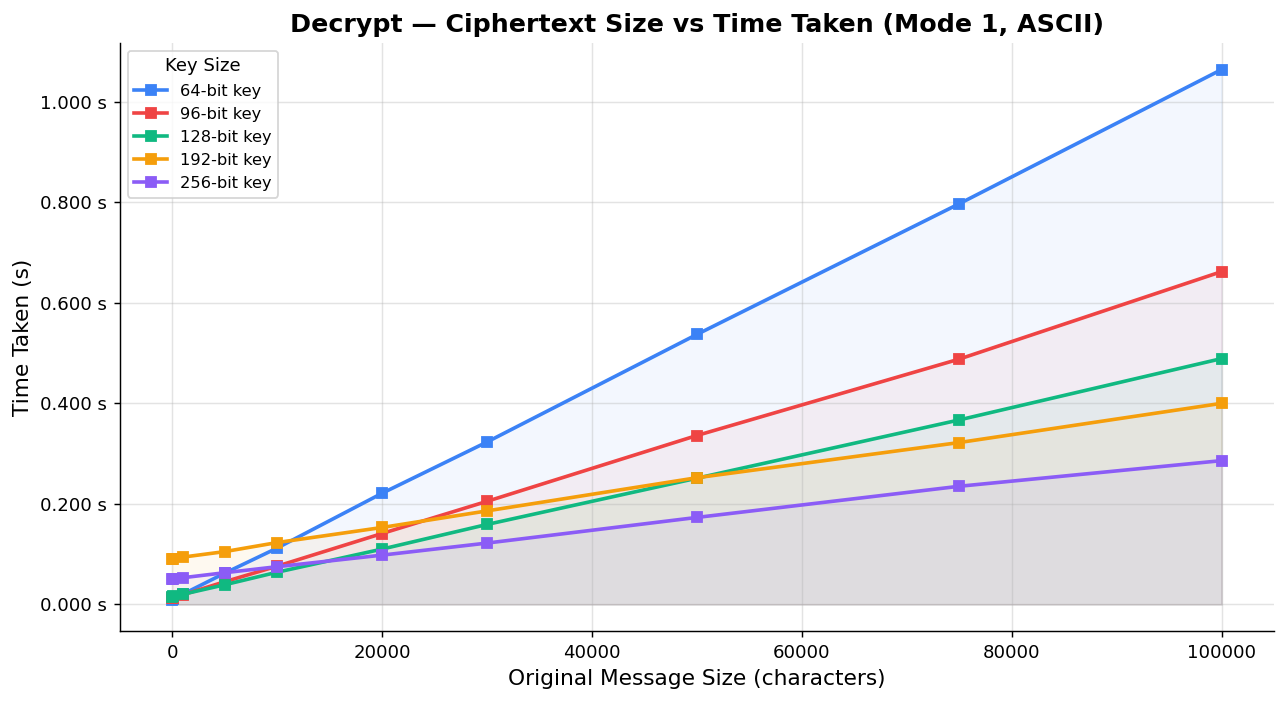

Saved → bench_decrypt.png


In [9]:
# ── Plot ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))

for idx, (bits, data) in enumerate(sorted(decrypt_results.items())):
    valid = [(x, y) for x, y in data if y is not None]
    if not valid:
        continue
    xs, ys = zip(*valid)
    color = COLOURS[idx % len(COLOURS)]
    ax.plot(xs, ys, "s-", color=color, linewidth=2,
            markersize=6, label=f"{bits}-bit key")
    ax.fill_between(xs, ys, alpha=0.06, color=color)

ax.set_xlabel("Original Message Size (characters)", fontsize=12)
ax.set_ylabel("Time Taken (s)", fontsize=12)
ax.set_title("Decrypt — Ciphertext Size vs Time Taken (Mode 1, ASCII)",
             fontsize=14, fontweight="bold")
ax.legend(title="Key Size", fontsize=9)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f s"))
plt.tight_layout()
plt.savefig("bench_decrypt.png", dpi=150)
plt.show()
print("Saved → bench_decrypt.png")

---
## 4  Combined Summary — All 3 Graphs Side by Side

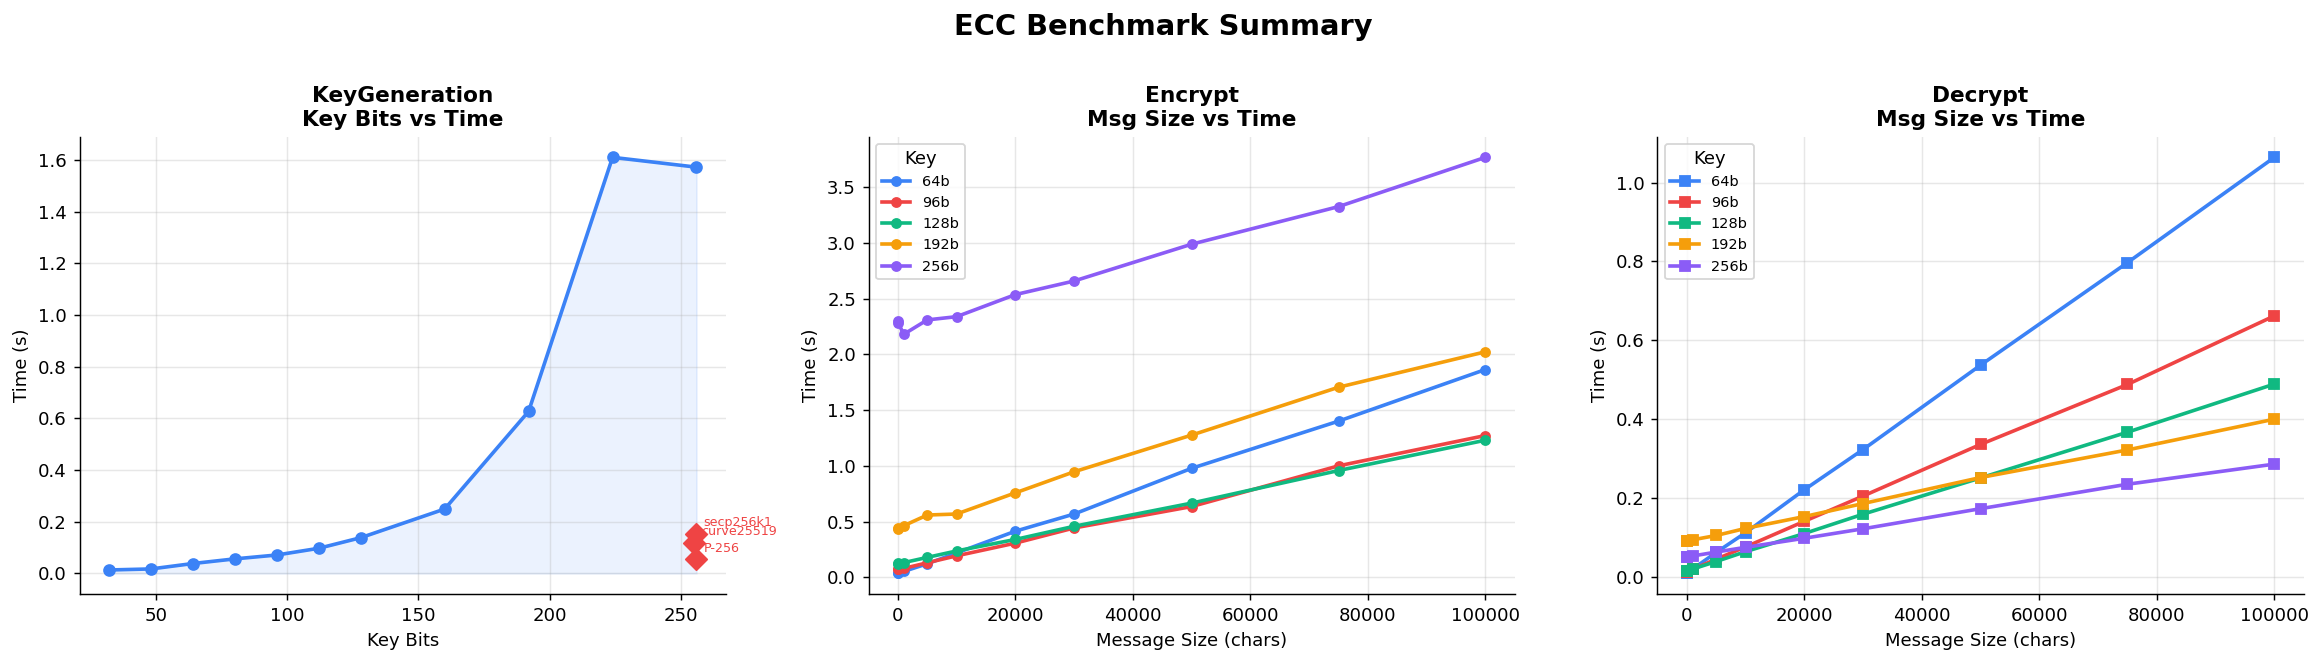

Saved → bench_summary.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ECC Benchmark Summary", fontsize=16, fontweight="bold", y=1.01)

# ── 1: KeyGen ──
ax = axes[0]
valid = [(b, t) for b, t in keygen_times if t is not None]
if valid:
    xs, ys = zip(*valid)
    ax.plot(xs, ys, "o-", color=COLOURS[0], linewidth=2, markersize=6)
    ax.fill_between(xs, ys, alpha=0.1, color=COLOURS[0])
for bits, t, name in predefined_pts:
    if t is not None:
        ax.scatter([bits], [t], zorder=5, s=70, marker="D", color=COLOURS[1])
        ax.annotate(name, (bits, t), textcoords="offset points",
                    xytext=(4, 4), fontsize=7, color=COLOURS[1])
ax.set_title("KeyGeneration\nKey Bits vs Time", fontweight="bold")
ax.set_xlabel("Key Bits")
ax.set_ylabel("Time (s)")

# ── 2: Encrypt ──
ax = axes[1]
for idx, (bits, data) in enumerate(sorted(encrypt_results.items())):
    valid = [(x, y) for x, y in data if y is not None]
    if valid:
        xs, ys = zip(*valid)
        ax.plot(xs, ys, "o-", color=COLOURS[idx % len(COLOURS)],
                linewidth=2, markersize=5, label=f"{bits}b")
ax.set_title("Encrypt\nMsg Size vs Time", fontweight="bold")
ax.set_xlabel("Message Size (chars)")
ax.set_ylabel("Time (s)")
ax.legend(title="Key", fontsize=8, loc="upper left")

# ── 3: Decrypt ──
ax = axes[2]
for idx, (bits, data) in enumerate(sorted(decrypt_results.items())):
    valid = [(x, y) for x, y in data if y is not None]
    if valid:
        xs, ys = zip(*valid)
        ax.plot(xs, ys, "s-", color=COLOURS[idx % len(COLOURS)],
                linewidth=2, markersize=5, label=f"{bits}b")
ax.set_title("Decrypt\nMsg Size vs Time", fontweight="bold")
ax.set_xlabel("Message Size (chars)")
ax.set_ylabel("Time (s)")
ax.legend(title="Key", fontsize=8, loc="upper left")

for a in axes:
    a.grid(True, alpha=0.3)
    a.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bench_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → bench_summary.png")

---
## 5  Raw Results Table

In [11]:
import pandas as pd

# KeyGen table
df_kg = pd.DataFrame(keygen_times, columns=["Key Bits", "Time (s)"])
df_kg["Time (s)"] = df_kg["Time (s)"].map(lambda x: f"{x:.4f}" if x is not None else "—")
print("=== KeyGeneration ===")
print(df_kg.to_string(index=False))

# Encrypt / Decrypt tables
for label, results in [("Encrypt", encrypt_results), ("Decrypt", decrypt_results)]:
    rows = {"Msg Chars": MSG_SIZES_BYTES}
    for bits, data in sorted(results.items()):
        col = []
        d = dict(data)
        for n in MSG_SIZES_BYTES:
            t = d.get(n)
            col.append(f"{t:.4f}" if t is not None else "—")
        rows[f"{bits}b key"] = col
    df = pd.DataFrame(rows)
    print(f"\n=== {label} ===")
    print(df.to_string(index=False))

=== KeyGeneration ===
 Key Bits Time (s)
       32   0.0130
       48   0.0170
       64   0.0380
       80   0.0560
       96   0.0710
      112   0.0970
      128   0.1380
      160   0.2490
      192   0.6270
      224   1.6100
      256   1.5720

=== Encrypt ===
 Msg Chars 64b key 96b key 128b key 192b key 256b key
        10  0.0360  0.0720   0.1240   0.4310   2.3010
       100  0.0370  0.0730   0.1280   0.4460   2.2780
      1000  0.0530  0.0800   0.1320   0.4630   2.1800
      5000  0.1220  0.1310   0.1790   0.5590   2.3090
     10000  0.2190  0.1930   0.2370   0.5680   2.3380
     20000  0.4140  0.3070   0.3400   0.7580   2.5360
     30000  0.5680  0.4430   0.4580   0.9470   2.6580
     50000  0.9780  0.6350   0.6660   1.2760   2.9880
     75000  1.4010  1.0000   0.9580   1.7050   3.3250
    100000  1.8640  1.2720   1.2300   2.0230   3.7670

=== Decrypt ===
 Msg Chars 64b key 96b key 128b key 192b key 256b key
        10  0.0090  0.0130   0.0150   0.0900   0.0510
       100  0.

---
## Notes

| Parameter | Value used | How to change |
|-----------|-----------|---------------|
| Repetitions per point | `RUNS = 3` (median) | Cell 1 |
| Key bit sizes | `KEY_BITS_TO_TEST` | Cell 5 |
| Message sizes | `MSG_SIZES_CHARS` | Cell 5 |
| KeyGen bit sweep | `BIT_SIZES` | Cell 3 |
| Timeout per run | `TIMEOUT = 600 s` | Cell 1 |

All timing values are taken directly from each script's own `Time Taken: X.XXXs` output,  
so they reflect **SageMath-internal** execution time, not subprocess overhead.